# Lasy losowe i gradient boosting #
## Wprowadzenie

Na poprzednich zajęciach pracowaliśmy z modelem **drzewa decyzyjnego**, analizując jego działanie na zbiorze danych *breast_cancer*.

W tym notebooku rozszerzymy tę wiedzę, przechodząc do dwóch bardzo ważnych rodzin modeli zespołowych (ang. *ensemble methods*):

- **Lasy losowe** (*Random Forest*, metoda bagging)
- **Gradient Boosting** (boosting drzew decyzyjnych)

Modele te bazują na drzewach decyzyjnych jako klasyfikatorach bazowych, ale różnią się sposobem, w jaki wykorzystują wiele drzew, aby poprawić jakość predykcji.

### 🔹 Bagging — Lasy losowe

**Random Forest** wykorzystuje koncepcję *baggingu* (bootstrap aggregating):
- trenuje **wiele niezależnych drzew decyzyjnych**,
- każde drzewo dostaje losową próbkę danych (z powtórzeniami),
- oraz losowy podzbiór cech przy podziale węzłów,
- a predykcja końcowa to **głosowanie większościowe** (lub średnia).

### 🔹 Boosting — Gradient Boosting

**Gradient Boosting** działa inaczej:
- drzewa budowane są **sekwencyjnie**, jedno po drugim,
- każde kolejne drzewo stara się **poprawić błędy poprzednich**,
- model uczy się „reszt błędu”, czyli tego, czego nie wyjaśniły wcześniejsze drzewa.

# Przygotowanie środowiska programistycznego

In [42]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
from termcolor import colored
from sklearn.metrics import roc_auc_score

# Załadowanie danych — **Pima Indians Diabetes Dataset**

W tym ćwiczeniu będziemy pracować ze zbiorem danych dotyczącym diagnozowania cukrzycy u kobiet z populacji Pima Indian. Jest to klasyczny, trudny zbiór używany w uczeniu maszynowym do testowania modeli klasyfikacyjnych.

Każdy wiersz reprezentuje jedną pacjentkę, a kolumny zawierają różne cechy kliniczne i demograficzne, które mogą mieć wpływ na wystąpienie cukrzycy typu 2. Celem jest przewidzenie zmiennej label, która informuje, czy u danej osoby wykryto cukrzycę (`1`) lub nie (`0`).

## Opis cech:

- **Pregnancies**  
  Liczba przebytych ciąż. Może być wskaźnikiem pewnych zmian metabolicznych lub hormonalnych.

- **Glucose**  
  Stężenie glukozy w osoczu po 2 godzinach od testu obciążenia glukozą.  
  **Najważniejsza cecha** w diagnozowaniu cukrzycy.

- **BloodPressure**  
  Ciśnienie tętnicze rozkurczowe (mm Hg).  
  Zbyt niskie lub zbyt wysokie wartości mogą wskazywać na problemy metaboliczne.

- **SkinThickness**  
  Grubość fałdu skórnego tricepsa (mm).  
  Koreluje z poziomem tkanki tłuszczowej.

- **Insulin**  
  Stężenie insuliny w surowicy po 2 godzinach (μU/ml).  
  Wskazuje na insulinooporność lub problemy z gospodarką glukozową.

- **BMI**  
  Wskaźnik masy ciała (*Body Mass Index*).  
  Wysokie BMI jest jednym z głównych czynników ryzyka cukrzycy.

- **DiabetesPedigreeFunction**  
  Wskaźnik określający skłonność genetyczną do cukrzycy na podstawie historii rodzinnej.  
  Wyższa wartość → większe ryzyko.

- **Age**  
  Wiek pacjentki.  
  Ryzyko cukrzycy zwiększa się wraz z wiekiem.

- **label**  
  Zmienna docelowa:  
  - `1` — cukrzyca wykryta  
  - `0` — brak diagnozy


W kolejnych zadaniach wykorzystamy ten zbiór danych do treningu i porównania modeli z rodziny drzew decyzyjnych.

In [43]:
url = "https://www.fuw.edu.pl/~mpoziomska/data/diabetes2.csv"
df = pd.read_csv(url, encoding='latin-1')
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            1      109             60              8      182  25.4   
1            4       83             86             19        0  29.3   
2            6       80             80             36        0  39.8   
3            4      151             90             38        0  29.7   
4            3       96             78             39        0  37.3   

   DiabetesPedigreeFunction  Age  label  
0                     0.947   21      0  
1                     0.317   34      0  
2                     0.177   28      0  
3                     0.294   36      0  
4                     0.238   40      0  


**Proszę:**
* podzielić dane na części uczącą i walidacyjną w proporcjach 80:20

**Uwaga**: można użyć parametru ```random_state=42``` by umożliwić porównanie wyników z innymi osobami

**Wskazówka**: proszę skorzystać z funkcji ```sklearn.model_selection.train_test_split```

In [44]:
...
pass

Train dataset:
 count    428.000000
mean       0.500000
std        0.500585
min        0.000000
25%        0.000000
50%        0.500000
75%        1.000000
max        1.000000
Name: label, dtype: float64
Test dataset:
 count    108.000000
mean       0.500000
std        0.502331
min        0.000000
25%        0.000000
50%        0.500000
75%        1.000000
max        1.000000
Name: label, dtype: float64


## Zadanie
Eksperyment z parametrami Random Forest — analiza AUC

W tym zadaniu przeprowadzimy bardziej zaawansowaną analizę klasyfikatora **RandomForestClassifier**, badając, jak parametry modelu wpływają na jego skuteczność.

**Proszę:**
1. Zainicjalizować i wytrenować modele **RandomForestClassifier** dla wielu kombinacji parametrów:
   - `n_estimators: [1, 5, 10, 50, 100]` - Określa liczbę drzew tworzonych w lesie
   - `max_depth: [1, 2, 4, 6, None]` - Maksymalna głębokość każdego drzewa.

2. Dla każdej kombinacji:
   - wytrenować model,
   - obliczyć **AUC**,
   - zapisać wynik.

3. Utworzyć **heatmapę**, która pokaże zależność AUC od `n_estimators` i `max_depth`.

---

### Wskazówka

Do obliczenia AUC możesz użyć:
```python
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])


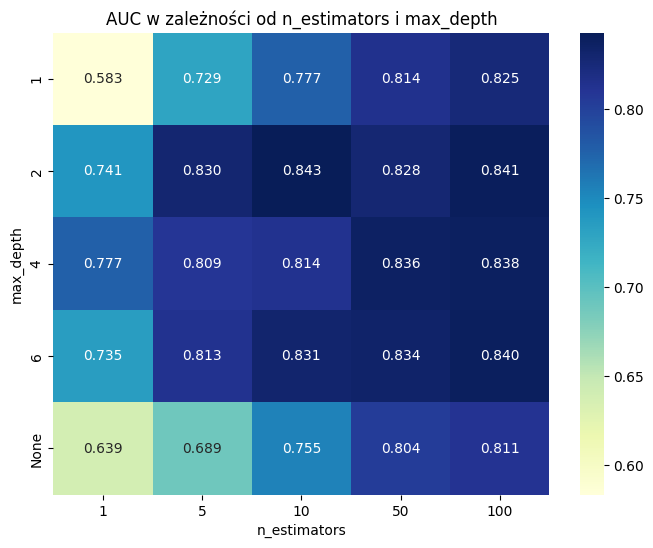

In [45]:
...


## Zadanie  
### Eksperyment z parametrami Gradient Boosting — analiza AUC

Teraz powtórzymy analogiczny eksperyment jak w przypadku Random Forest, ale użyjemy modelu **GradientBoostingClassifier**.

Gradient Boosting łączy wiele płytkich drzew decyzyjnych tworzonych sekwencyjnie — każde kolejne drzewo stara się poprawić błędy poprzednich.

**Proszę:**

1. Przetestować model **GradientBoostingClassifier** dla wielu kombinacji parametrów:
   - `n_estimators: [10, 50, 100, 200]` — liczba drzew w sekwencji boostingowej  
   - `learning_rate: [0.01, 0.05, 0.1, 0.2]` — szybkość uczenia (mniejsza → model uczy się wolniej, ale stabilniej)

2. Dla każdej kombinacji parametrów:
   - wytrenować model,
   - obliczyć AUC na zbiorze testowym,
   - zapisać wynik do tabeli.

3. Utworzyć **heatmapę**, która pokaże wpływ `n_estimators` i `learning_rate` na AUC.


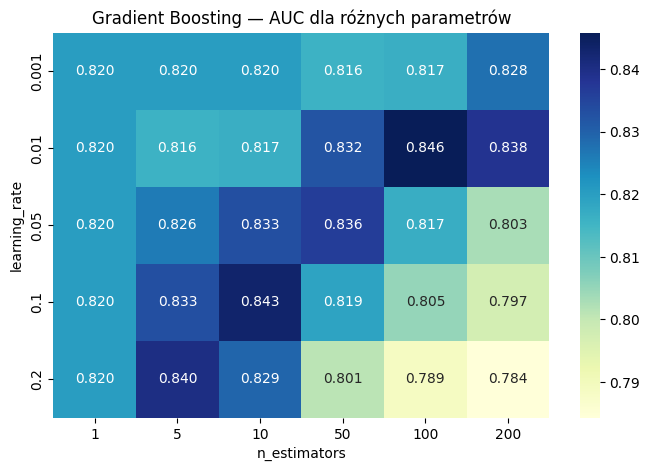

In [46]:
...


# Zadanie: Porównanie modeli drzewiastych — wybór najlepszych parametrów i walidacja krzyżowa

W tym zadaniu porównamy trzy modele oparte na drzewach decyzyjnych:

1. **Drzewo decyzyjne** 
2. **Random Forest**
3. **Gradient Boosting** 

---
**Proszę:**
- Wybrać po jednym zestawie najlepszych parametrów dla RF i GB.
- Z poprzednich zajęć odszukać najlepsze parametry dla **Drzewa Decyzyjnego**
- Zainicjalizować model z **wybranymi najlepszymi parametrami**
- Przeprowadzić **5-krotną walidację krzyżową** (`cross_val_score`) na całym zbiorze danych
- Jako metrykę wybrać AUC
- Wypisać średnią i odchylenie standardowe dla trzech modeli


In [47]:
...


Decision Tree Classifier CV AUC: 0.7991 ± 0.0433
Random Forest Classifier CV AUC: 0.8092 ± 0.0359
Gradient Boosting Classifier CV AUC: 0.8228 ± 0.0427



## Zadanie  
### Analiza ważności cech (Feature Importance) w Random Forest i Gradient Boosting

Modele drzewiaste mają tę zaletę, że potrafią oszacować **ważność cech** — czyli informują, które atrybuty najbardziej wpływają na decyzję modelu.

W tym zadaniu porównamy ważność cech między:
- najlepszym modelem **Random Forest** (z poprzedniego zadania),
- najlepszym modelem **Gradient Boosting** (wybranym z poprzedniego ćwiczenia).

**Proszę:**

1. Wytrenować:
   - model Random Forest z optymalnymi parametrami (wybrany wcześniej),
   - model Gradient Boosting z parametrami, które dały najwyższe AUC.

2. Wyciągnąć wektory `feature_importances_` dla każdego modelu.

3. Stworzyć wykresy:
   - osobny wykres słupkowy dla Random Forest,
   - osobny wykres słupkowy dla Gradient Boosting,
   - dodatkowo: **jeden wspólny wykres**, który pokazuje różnice obok siebie  
     (np. porównanie RF vs GB dla każdej cechy).

4. Odpowiedzieć na pytania:
   - Które cechy mają najwyższe znaczenie w obu modelach?
   - Czy modele zgadzają się co do rankingu cech?
   - Czy któryś model wydaje się bardziej „skoncentrowany” na mniejszej liczbie cech?

**Wskazówka:**  
Wykres słupkowy możesz stworzyć np. tak:

```python
importances = model.feature_importances_
plt.barh(features, importances)


In [48]:
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

rf_importances = rf_model.feature_importances_
gb_importances = gb_model.feature_importances_
features = X_train.columns

df_imp = pd.DataFrame({
    "feature": features,
    "RF": rf_importances,
    "GB": gb_importances
}).set_index("feature")


fig = go.Figure()

fig.add_trace(go.Bar(
    y=df_imp.index,
    x=df_imp["RF"],
    orientation='h',
    name='Random Forest',
    opacity=0.7
))

fig.add_trace(go.Bar(
    y=df_imp.index,
    x=df_imp["GB"],
    orientation='h',
    name='Gradient Boosting',
    opacity=0.7
))

fig.update_layout(
    title="Porównanie feature importance: Random Forest vs Gradient Boosting",
    xaxis_title="Importance",
    yaxis_title="Feature",
    barmode='group',
    height=600
)

fig.show()



# Zadanie domowe — Klasyfikacja na zbiorze **Titanic** z użyciem **CatBoost**

## Przypomnienie

Zbiór **Titanic** to klasyczny dataset używany w uczeniu maszynowym. Zawiera informacje o pasażerach słynnego statku, takie jak:
- wiek,
- płeć,
- klasa biletu,
- liczba członków rodziny na pokładzie,
- cena biletu,
- port zaokrętowania,

oraz zmienną docelową **Survived**, która określa, czy dany pasażer przeżył katastrofę.

---

## Wprowadzenie — model **CatBoost**

**CatBoost** (Categorical Boosting) to nowoczesny model gradient boosting, który:
- **natywnie obsługuje dane kategoryczne**,
- jest odporny na overfitting,
- dobrze działa nawet przy niewielkiej liczbie próbek,
- często przewyższa jakością modele takie jak Random Forest czy klasyczny Gradient Boosting, gdy zbiór zawiera wiele zmiennych kategorycznych.

W tym zadaniu użyjemy CatBoostClassifier.

---

## Zadanie
 
1. Zidentyfikuj kolumny **kategoryczne**.
3. Wybierz cechy, które według Ciebie nadają się do predykcji czy dany pasażer przeżyje.
4. Usuń wiersze, dla których są brakujące wartości.
2. Zainicjalizuj model:
   - użyj `CatBoostClassifier`,
   - wyłącz wypisywanie logów (`verbose=False`),
3. Przeprowadź **5-foldową walidację krzyżową** z metryką **AUC**.
4. Wypisz średnią oraz odchylenie standardowe AUC.
5. Narysuj historie uczenia modelu dla każdego z foldów.

---

### Wskazówki

- Użyj:
  ```python
  from catboost import CatBoostClassifier
    

In [51]:

from sklearn.datasets import fetch_openml
data = fetch_openml(name='titanic', version=1, as_frame=True)
df = data.frame
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [50]:
...



CatBoost AUC scores: [0.8866641832743528, 0.8280033370411569, 0.865748709122203, 0.8759398496240602, 0.8813493975903613]
CatBoost AUC mean: 0.8675
CatBoost AUC std: 0.0234
